# Task 7: Time Series Breakdown of Retail Sales

## **Author:**  `Awais Manzor`





## Step 1: Import Required Libraries


In [24]:

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimpy import skim



# Configure plots
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (10, 6)


## Step 2: Load and Explore Dataset

In [9]:

df = pd.read_csv("c:/Users/hp/Downloads/train.csv")

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (421570, 5)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [25]:
df = pd.read_csv("c:/Users/hp/Downloads/train.csv")
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 421570 │ │ int64       │ 2     │                                                          │
│ │ Number of columns │ 5      │ │ string      │ 1     │                                                          │
│ └───────────────────┴────────┘ │ float64     │ 1     │                                                          │
│                                │ bool        │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column           ┃ NA  ┃ NA %   ┃ mean    ┃ sd      ┃ p0      ┃ p25   ┃ p50   ┃ p75    ┃ p100    ┃ hist    ┃  │
│ ┡━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━┩  │
│ │ Store            │   0 │      0 │    22.2 │   12.79 │       1 │    11 │    22 │     33 │      45 │ ▇▇▇▇▆▇  │  │
│ │ Dept             │   0 │      0 │   44.26 │   30.49 │       1 │    18 │    37 │     74 │      99 │ ▇▇▅▃▃▆  │  │
│ │ Weekly_Sales     │   0 │      0 │   15980 │   22710 │   -4989 │  2080 │  7612 │  20210 │  693100 │    ▇    │  │
│ └──────────────────┴─────┴────────┴─────────┴─────────┴─────────┴───────┴───────┴────────┴─────────┴─────────┘  │
│                                                      bool                                                       │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column                         ┃ true               ┃ true rate                     ┃ hist                 ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩  │
│ │ IsHoliday                      │              29661 │                          0.07 │        ▇    ▁        │  │
│ └────────────────────────────────┴────────────────────┴───────────────────────────────┴──────────────────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┓  │
│ ┃        ┃    ┃      ┃            ┃            ┃           ┃            ┃ chars per ┃ words per  ┃ total     ┃  │
│ ┃ column ┃ NA ┃ NA % ┃ shortest   ┃ longest    ┃ min       ┃ max        ┃ row       ┃ row        ┃ words     ┃  │
│ ┡━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━┩  │
│ │ Date   │  0 │    0 │ 2010-02-05 │ 2010-02-05 │ 2010-02-0 │ 2012-10-26 │        10 │          1 │    421570 │  │
│ │        │    │      │            │            │ 5         │            │           │            │           │  │
│ └────────┴────┴──────┴────────────┴────────────┴───────────┴────────────┴───────────┴────────────┴───────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

#  Clean Column Names

In [ ]:

df.columns = df.columns.str.strip().str.lower()
print("Columns after cleaning:", df.columns.tolist())


Columns after cleaning: ['store', 'dept', 'date', 'weekly_sales', 'isholiday']


# Convert Data Types

In [ ]:

df['date'] = pd.to_datetime(df['date'], errors='coerce')


df['weekly_sales'] = pd.to_numeric(df['weekly_sales'], errors='coerce')

print(df.dtypes)


store                    int64
dept                     int64
date            datetime64[ns]
weekly_sales           float64
isholiday                 bool
dtype: object


# Handle Missing Values


In [ ]:
print("Missing values before cleaning:\n", df.isnull().sum())

df = df.dropna(subset=['date', 'weekly_sales'])
print("Shape after cleaning:", df.shape)


Missing values before cleaning:
 store           0
dept            0
date            0
weekly_sales    0
isholiday       0
dtype: int64
Shape after cleaning: (421570, 5)


# Summary Statistics

In [ ]:

print("\nSummary Statistics for Weekly Sales:")
print(df['weekly_sales'].describe())



Summary Statistics for Weekly Sales:
count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: weekly_sales, dtype: float64


# Exploratory Data Analysis (EDA)


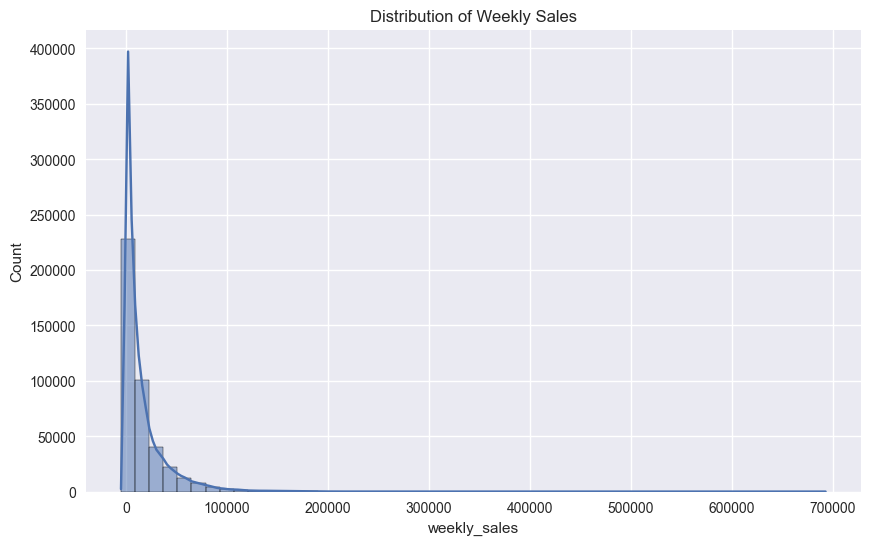

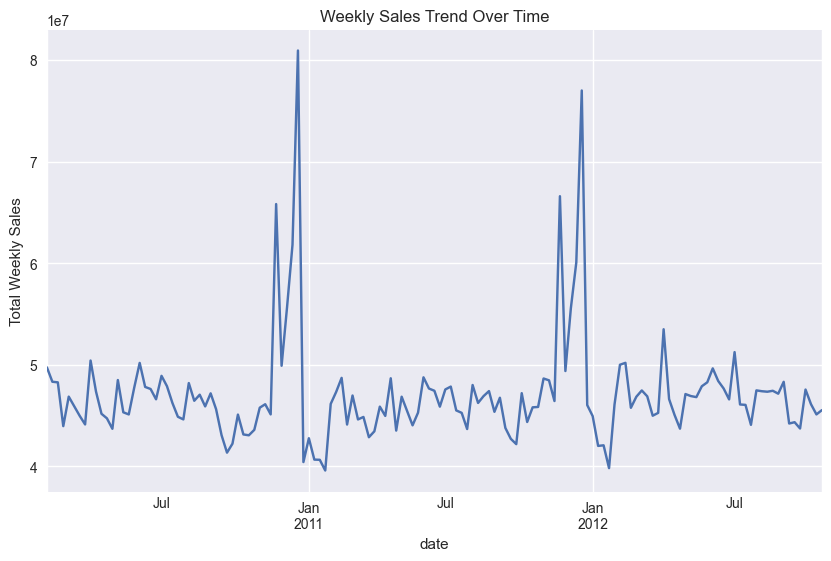

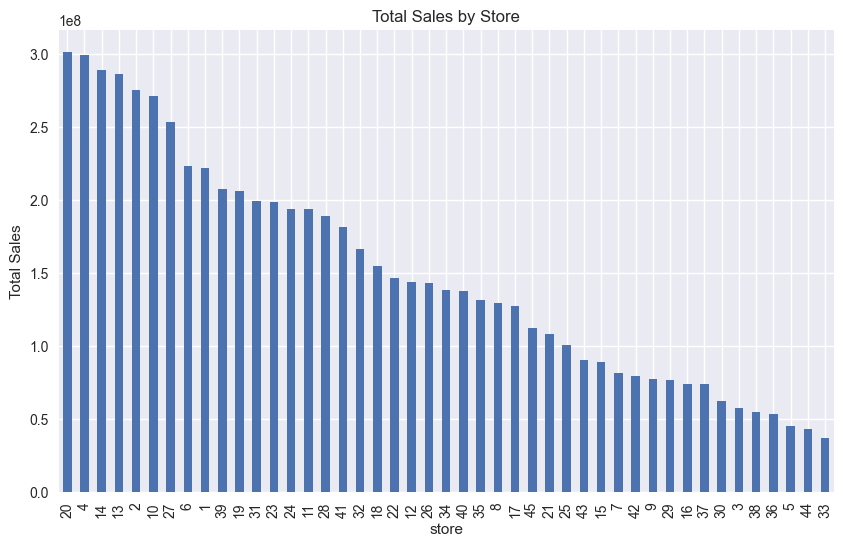

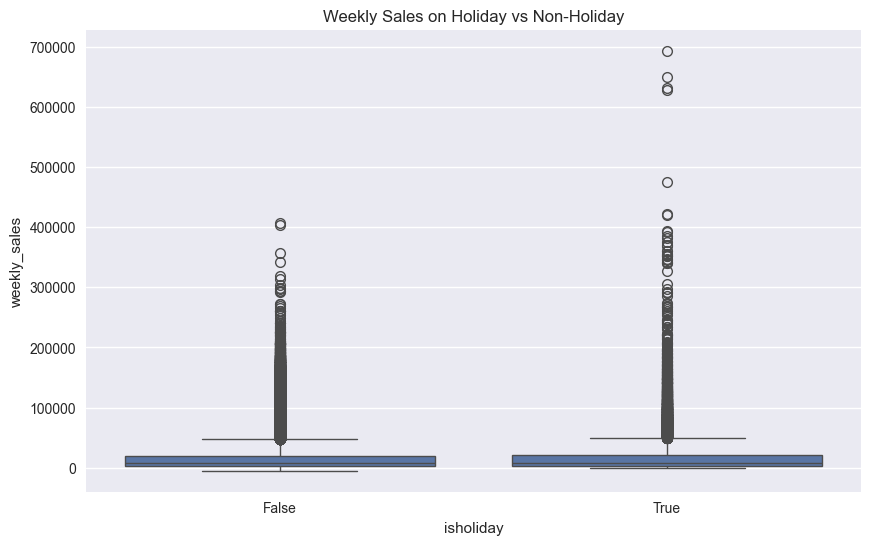

In [ ]:


# Weekly Sales 
sns.histplot(df['weekly_sales'], bins=50, kde=True)
plt.title("Distribution of Weekly Sales")
plt.show()

# Sales Trend
df.groupby('date')['weekly_sales'].sum().plot()
plt.title("Weekly Sales Trend Over Time")
plt.ylabel("Total Weekly Sales")
plt.show()

# Sales by Store
store_sales = df.groupby('store')['weekly_sales'].sum().sort_values(ascending=False)
store_sales.plot(kind='bar')
plt.title("Total Sales by Store")
plt.ylabel("Total Sales")
plt.show()

# Holiday vs Non-Holiday Sales
sns.boxplot(x='isholiday', y='weekly_sales', data=df)
plt.title("Weekly Sales on Holiday vs Non-Holiday")
plt.show()


In [16]:
['store', 'date', 'temperature', 'fuel_price', 
 'markdown1', 'markdown2', 'markdown3', 'markdown4', 'markdown5', 
 'cpi', 'unemployment', 'isholiday', 'weekly_sales']


['store',
 'date',
 'temperature',
 'fuel_price',
 'markdown1',
 'markdown2',
 'markdown3',
 'markdown4',
 'markdown5',
 'cpi',
 'unemployment',
 'isholiday',
 'weekly_sales']

# Correlation Analysis

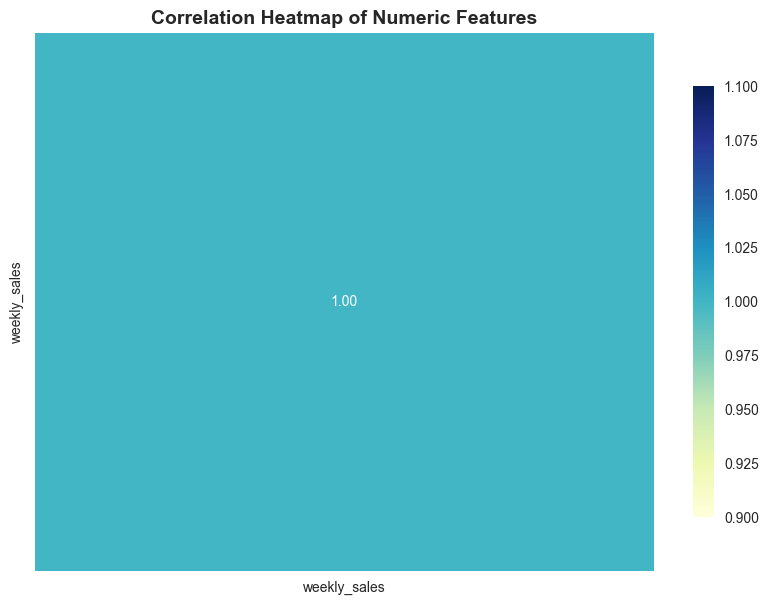

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

# Ensure column names are clean
df.columns = df.columns.str.strip().str.lower()


numeric_cols = [col for col in ['weekly_sales', 'temperature', 'fuel_price', 'cpi', 'unemployment'] if col in df.columns]

# Correlation Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    df[numeric_cols].corr(), 
    annot=True, 
    cmap="YlGnBu", 
    fmt=".2f", 
    linewidths=0.5, 
    cbar_kws={'shrink': 0.8}
)
plt.title("Correlation Heatmap of Numeric Features", fontsize=14, fontweight='bold')
plt.show()


# Sales Trend

C:\Users\hp\AppData\Local\Temp\ipykernel_9560\4187570126.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.groupby(pd.Grouper(key='date', freq='M'))['weekly_sales'].sum()


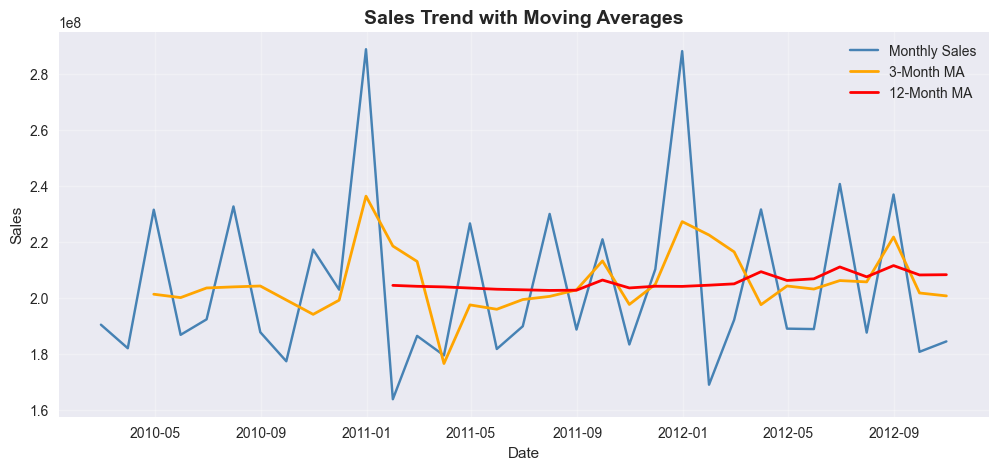

In [ ]:

monthly_sales = df.groupby(pd.Grouper(key='date', freq='M'))['weekly_sales'].sum()

# Calculate moving averages
ma3 = monthly_sales.rolling(window=3).mean()
ma12 = monthly_sales.rolling(window=12).mean()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales, label='Monthly Sales', color='steelblue')
plt.plot(ma3, label='3-Month MA', color='orange', linewidth=2)
plt.plot(ma12, label='12-Month MA', color='red', linewidth=2)

plt.title('Sales Trend with Moving Averages', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Seasonal Decomposition of Sales


C:\Users\hp\AppData\Local\Temp\ipykernel_9560\2810588554.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.groupby(pd.Grouper(key='date', freq='M'))['weekly_sales'].sum()


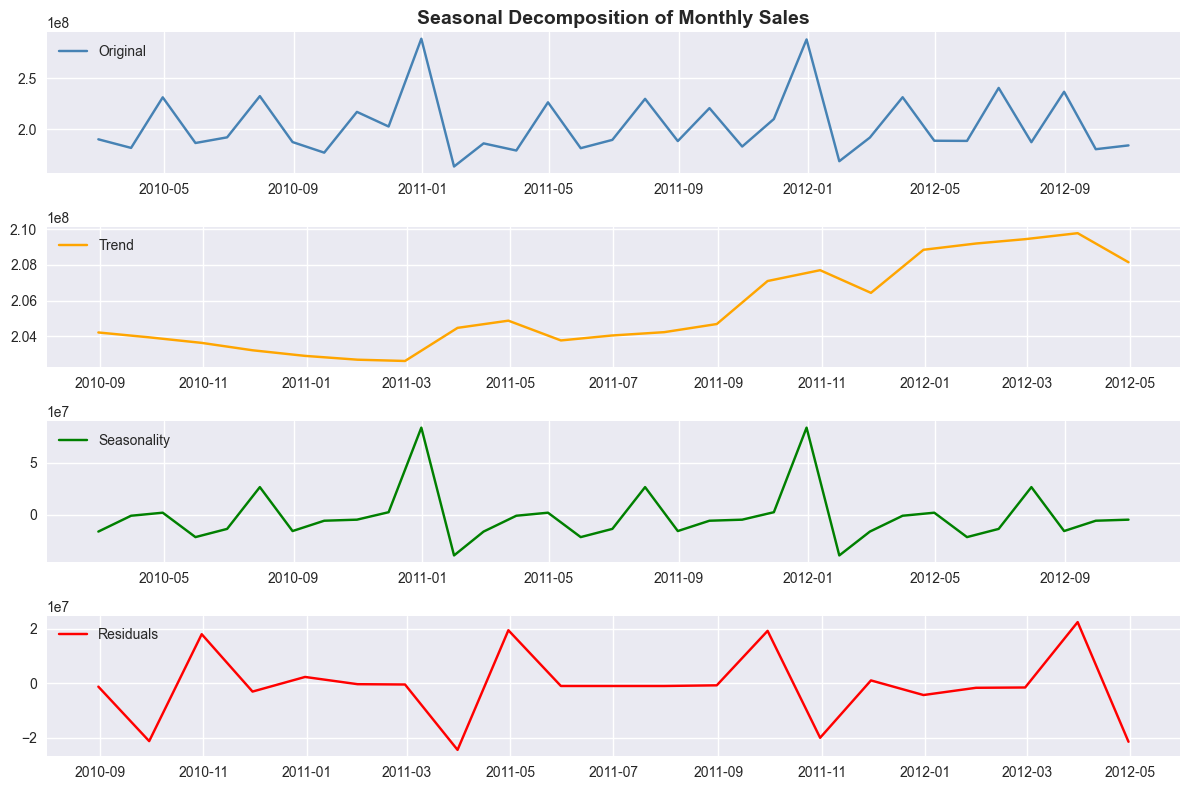

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

monthly_sales = df.groupby(pd.Grouper(key='date', freq='M'))['weekly_sales'].sum()


decomposition = seasonal_decompose(monthly_sales, model='additive', period=12)


plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(monthly_sales, label='Original', color='steelblue')
plt.title('Seasonal Decomposition of Monthly Sales', fontsize=14, fontweight='bold')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='orange')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonality', color='green')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(decomposition.resid, label='Residuals', color='red')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()
